# Final Assignment - Web Scraping

### Assignment Instructions

Web scraping exercise

Using libraries of your choice, scrape [this census page](https://www.census2011.co.in/city.php) and create a DataFrame called `cities` containing the first table from that page. *(Note: make sure to convert the variables `Population` and `Literacy` to numeric, you will need them later)*
1. Which City has the highest levels of `Literacy` in the country?
2. Merge the `cities` table with the `sps_fnd_loc` in a new DataFrame called `sps_fnd_loc_lit`. The resulting DataFrame is missing one row compared to the `sps_fnd_loc` dataset. Which `City` is missing? Figure out why and fix the problem. 
3. Looking at the new `sps_fnd_loc_lit` DataFrame, produce a scatterplot that shows `Literacy` on the x-axis, `Avg. Salary` on the y-axis and the `Population` as the size of the circles. Try also to add the `City` labels to each circle in the chart. There seems to be a positive direct relationship between the two variables (higher levels of literacy correspond to higher salaries), but there is one city that escapes this interpretation. Which city is it? Try to describe the chart and give your interpretation. 

In [ ]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [ ]:
# Save the url as a variable
url = "https://www.census2011.co.in/city.php"

# Use the build-in pandas 'read_html()' method to 
# parse the html and extract the table with BeautifulSoup
cities = pd.read_html(url)[0]
cities.info()

<class 'pandas.DataFrame'>
RangeIndex: 498 entries, 0 to 497
Data columns (total 7 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   #             498 non-null    int64  
 1   City          498 non-null    str    
 2   State         498 non-null    str    
 3   Population    498 non-null    int64  
 4   Metropolitan  498 non-null    int64  
 5   Sexratio      498 non-null    int64  
 6   Literacy      498 non-null    float64
dtypes: float64(1), int64(4), str(2)
memory usage: 27.4 KB


In [ ]:
# Drop the first column containing no informations
cities = cities.drop(columns = "#")
cities.head()

,City,State,Population,Metropolitan,Sexratio,Literacy
0,Mumbai,Maharashtra,12442373,18414288,853,89.73
1,Delhi,Delhi,11034555,16314838,876,87.59
2,Bangalore,Karnataka,8443675,8499399,923,88.71
3,Hyderabad,Andhra Pradesh,6731790,7749334,955,83.26
4,Ahmedabad,Gujarat,5577940,6352254,898,88.29


1. Which City has the highest levels of `Literacy` in the country?

In [ ]:
# Finding the row with the highest literacy
idx_max_lit = cities['Literacy'].idxmax()
# Save the city name and literacy value in a pandas series
top_lit = cities.loc[idx_max_lit, ['City', 'Literacy']]

# Use the f string inside the print to access first the name and then the value using iloc[]
print(f"The city with the highest levels of 'Literacy' is '{top_lit.iloc[0]}' with a 'Literacy' level of: {top_lit.iloc[1]}")

The city with the highest levels of 'Literacy' is 'Aizawl' with a 'Literacy' level of: 98.36


2. Merge the `cities` table with the `sps_fnd_loc` in a new DataFrame called `sps_fnd_loc_lit`. The resulting DataFrame is missing one row compared to the `sps_fnd_loc` dataset. Which `City` is missing? Figure out why and fix the problem. 

In [ ]:
# Load the 'sps_fnd_loc' df previously generated in the second final assignment
sps_fnd_loc = pd.read_csv('data/sps_fnd_loc.csv')
sps_fnd_loc.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 6 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Unnamed: 0            8 non-null      int64  
 1   City                  8 non-null      str    
 2   Avg. Rating           8 non-null      float64
 3   Avg. Salary           8 non-null      float64
 4   Nr. Companies Funded  8 non-null      int64  
 5   Sum Funding ($MM)     8 non-null      float64
dtypes: float64(3), int64(2), str(1)
memory usage: 516.0 bytes


In [ ]:
# Through .info() emerged the previous index column 
# was treated as an actual column and needs to be removed
sps_fnd_loc = sps_fnd_loc.drop(columns='Unnamed: 0')
sps_fnd_loc.info()

<class 'pandas.DataFrame'>
RangeIndex: 8 entries, 0 to 7
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   City                  8 non-null      str    
 1   Avg. Rating           8 non-null      float64
 2   Avg. Salary           8 non-null      float64
 3   Nr. Companies Funded  8 non-null      int64  
 4   Sum Funding ($MM)     8 non-null      float64
dtypes: float64(3), int64(1), str(1)
memory usage: 452.0 bytes


In [ ]:
# Proceed with the join of the two df, 
# using the 'inner' method to consider only common 'Cities'
sps_fnd_loc_lit = cities.merge(sps_fnd_loc, how='inner', on='City')
sps_fnd_loc_lit

,City,State,Population,Metropolitan,Sexratio,Literacy,Avg. Rating,Avg. Salary,Nr. Companies Funded,Sum Funding ($MM)
0,Mumbai,Maharashtra,12442373,18414288,853,89.73,3.881709,961180.368491,200,153830.30
1,Bangalore,Karnataka,8443675,8499399,923,88.71,3.920232,735344.739593,425,14327.42
2,Hyderabad,Andhra Pradesh,6731790,7749334,955,83.26,3.914484,679099.157376,34,243.96
3,Chennai,Tamil Nadu,4646732,8696010,989,90.18,3.902726,584559.661513,40,717.14
4,Kolkata,West Bengal,4496694,14112536,908,86.31,4.024719,710925.573034,5,28.00
5,Pune,Maharashtra,3124458,5049968,948,89.56,3.886082,690476.311153,46,509.07
6,Jaipur,Rajasthan,3046163,3046163,900,83.33,3.940741,629135.802469,11,343.30


In [ ]:
# Identify the difference between the two datasets by converting the 'City' columns 
# from both DataFrames into sets and using the '-' to find the difference
missing = set(sps_fnd_loc["City"]) - set(sps_fnd_loc_lit["City"])

# Convert the 'missing' set back to a list to access the first element via index [0].
# Then use the f-string to output the result and answer the question
print(f"""The missing city in the 'sps_fnd_loc_lit' df is '{list(missing)[0]}'. 
That is because in the 'cities' df it is called 'Delhi'.""")

The missing city in the 'sps_fnd_loc_lit' df is 'New Delhi'. 
That is because in the 'cities' df it is called 'Delhi'.


In [23]:
# Replace the 'Delhi' value in 'cities' with 'New Delhi' to match with 'sps_fnd_loc' value
cities['City'] = cities['City'].replace('Delhi', 'New Delhi')
cities.head()

,City,State,Population,Metropolitan,Sexratio,Literacy
0,Mumbai,Maharashtra,12442373,18414288,853,89.73
1,New Delhi,Delhi,11034555,16314838,876,87.59
2,Bangalore,Karnataka,8443675,8499399,923,88.71
3,Hyderabad,Andhra Pradesh,6731790,7749334,955,83.26
4,Ahmedabad,Gujarat,5577940,6352254,898,88.29


In [ ]:
# Repeat the join above to update the 'sps_fnd_loc_lit' df
sps_fnd_loc_lit = cities.merge(sps_fnd_loc, how='inner', on='City')
sps_fnd_loc_lit

,City,State,Population,Metropolitan,Sexratio,Literacy,Avg. Rating,Avg. Salary,Nr. Companies Funded,Sum Funding ($MM)
0,Mumbai,Maharashtra,12442373,18414288,853,89.73,3.881709,961180.368491,200,153830.30
1,New Delhi,Delhi,11034555,16314838,876,87.59,3.943415,658756.735632,143,1673.01
2,Bangalore,Karnataka,8443675,8499399,923,88.71,3.920232,735344.739593,425,14327.42
3,Hyderabad,Andhra Pradesh,6731790,7749334,955,83.26,3.914484,679099.157376,34,243.96
4,Chennai,Tamil Nadu,4646732,8696010,989,90.18,3.902726,584559.661513,40,717.14
5,Kolkata,West Bengal,4496694,14112536,908,86.31,4.024719,710925.573034,5,28.00
6,Pune,Maharashtra,3124458,5049968,948,89.56,3.886082,690476.311153,46,509.07
7,Jaipur,Rajasthan,3046163,3046163,900,83.33,3.940741,629135.802469,11,343.30


3. Looking at the new `sps_fnd_loc_lit` DataFrame, produce a scatterplot that shows `Literacy` on the x-axis, `Avg. Salary` on the y-axis and the `Population` as the size of the circles. Try also to add the `City` labels to each circle in the chart. There seems to be a positive direct relationship between the two variables (higher levels of literacy correspond to higher salaries), but there is one city that escapes this interpretation. Which city is it? Try to describe the chart and give your interpretation. 

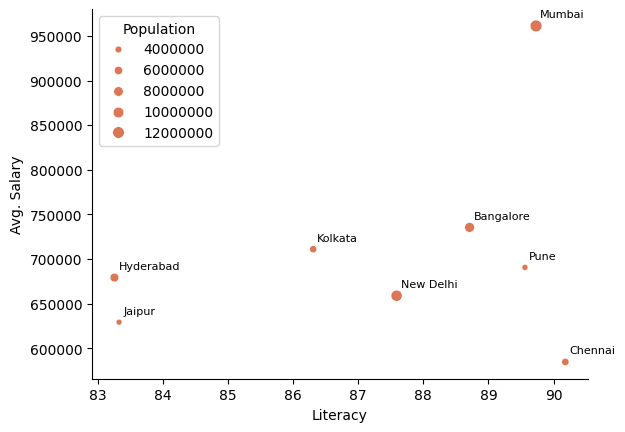

In [ ]:
# 1. Create the scatter plot
ax = sns.scatterplot(
    data = sps_fnd_loc_lit, 
    x = 'Literacy', 
    y = 'Avg. Salary', 
    size = 'Population', # Scale the points based on 'Population' to add a third dimension of data.
    color = '#d97757'
)
sns.despine()

# 2. Add text labels to each point
# Iterate through each row of the dataframe to add the City names.
for _, row in sps_fnd_loc_lit.iterrows():
    ax.annotate(
        row['City'],                                # The label text
        (row['Literacy'], row['Avg. Salary']),      # The (x, y) coordinates for the point
        xytext = (3, 6),                            # Offset the text slightly
        textcoords = 'offset points',               # Treat xytext as a relative shift, not absolute
        fontsize = 8                                # Set a smaller font to avoid clutter
    )

In [ ]:
# Find the 'anomaly' via filtering of the df for ['Literacy'] > 90
anomaly = sps_fnd_loc_lit[sps_fnd_loc_lit['Literacy'] > 90]['City'].iloc[0]

# Print the plot description and interpretation
print(f"""The chart shows a clear positive relationship between literacy and average salary, 
with 'Mumbai' appearing as expected at the top end due to its role as India's financial and corporate hub, 
while '{anomaly}' breaks the pattern by exhibiting relatively low salaries despite high literacy, 
likely reflecting differences in industry structure and wage dynamics rather than human capital alone.""")

The chart shows a clear positive relationship between literacy and average salary, 
with 'Mumbai' appearing as expected at the top end due to its role as India's financial and corporate hub, 
while 'Chennai' breaks the pattern by exhibiting relatively low salaries despite high literacy, 
likely reflecting differences in industry structure and wage dynamics rather than human capital alone.
